In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import profileNo_vs_xy_bins, sample_cap_bins_xy, cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34

In [2]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to contain the relevant features
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]','Profile_Number']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month','Profile_Number']]

# Calculate potential vorticity
df_ST = calc_pv(df_ST)

In [3]:
df_ST.head()

,Conservative_Temperature_[deg_C],Absolute_Salinity_[PSU],Dissolved_Oxygen_[micro_mol_per_kg],Depth_[m],Latitude_[deg_N],Longitude_[deg_E],year,month,Profile_Number,Pv
0,9.222,35.352,NaN,15.0,63.315,-0.075,2009,8,1,1.572741e-08
1,7.958,35.402,NaN,105.0,63.317,-0.017,2009,8,1,-2.711059e-10
2,7.831,35.402,NaN,115.0,63.318,-0.090,2009,8,1,-2.050461e-10
3,7.724,35.400,NaN,125.0,63.309,-0.068,2009,8,1,-3.112159e-10
4,7.550,35.395,NaN,135.0,63.368,-0.018,2009,8,1,-3.764021e-11


In [4]:
# Define random master seed for reproducibility
master_seed = 22
random.seed(master_seed)

# Define a list of random seeds
seeds = random.sample(range(1, 10000), 10)

In [5]:
# Define features to use for clustering
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]','Pv']

In [6]:
df_sampled = method34(df=df_ST, seed=master_seed)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:1026: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [159]:
# Run BIC score calculation for different numbers of clusters and for 10 different seeds
# Do BIC and AIC calculation for different number of clusters
all_scores = {}
n_components_range = range(1, 8)
for i,seed in enumerate(seeds[0:5]):
    bic_scores = [] 
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
        gmm.fit(df_ST[features])
        bic_scores.append(gmm.bic(df_ST[features]))

    all_scores[i] = bic_scores

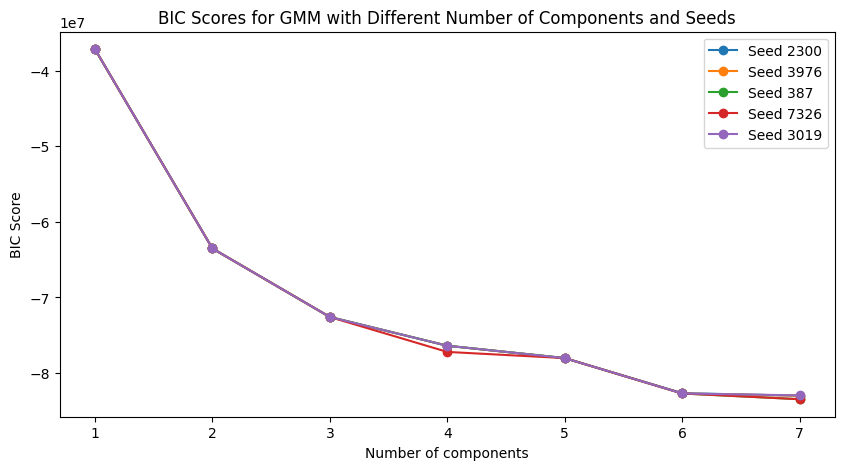

In [162]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.plot(n_components_range, all_scores[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components and Seeds')
plt.legend()

In [12]:
# Choice of optimal number of clusters based on BIC
n_clusters = 6

In [24]:
gmm_0 = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seeds[0])

labels_0 = gmm_0.fit_predict(df_sampled[features])

In [25]:
gmm_1 = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seeds[1])

labels_1 = gmm_1.fit_predict(df_sampled[features])

In [32]:
df_sampled['gmm_label_6'] = labels_0
df_sampled['gmm_label_6'] = labels_1

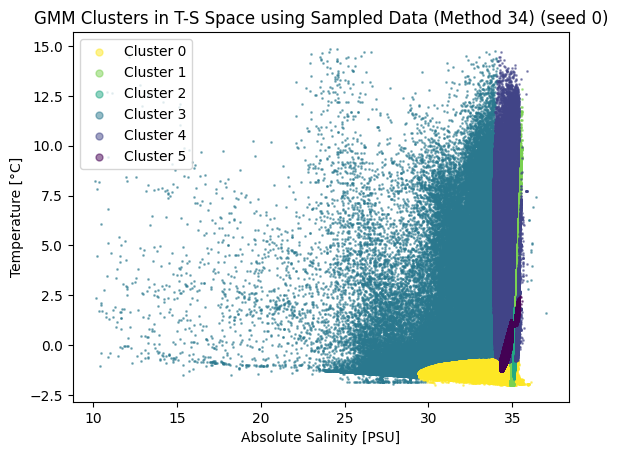

In [30]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34) (seed 0)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



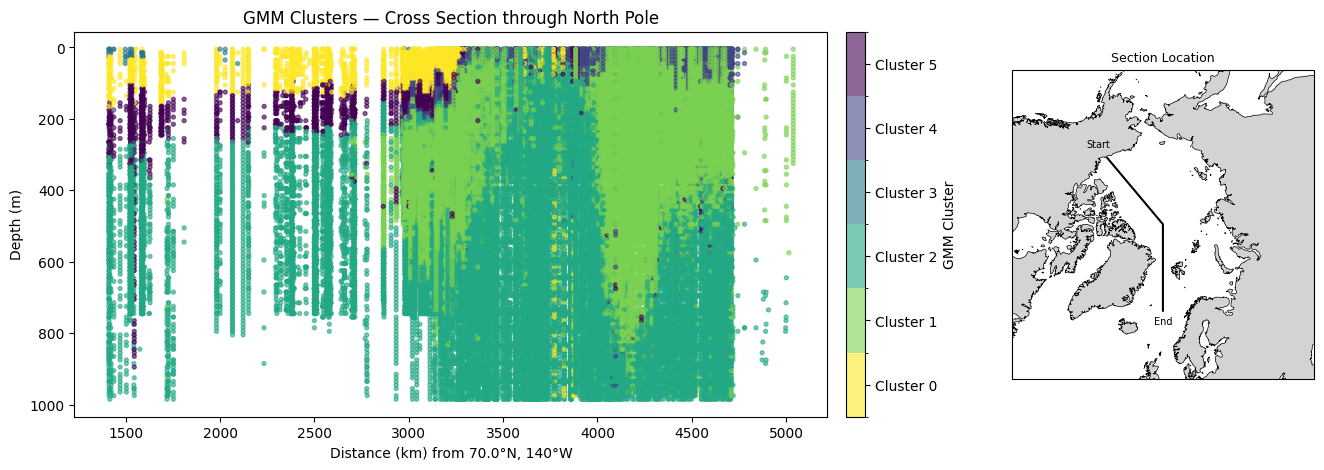

In [31]:
cross_sec_lon(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

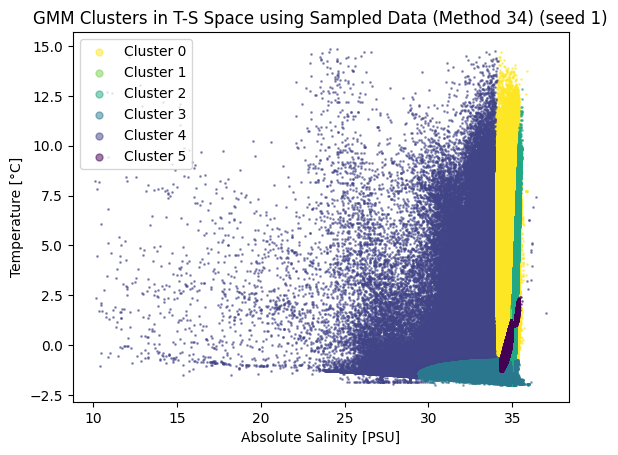

In [33]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34) (seed 1)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



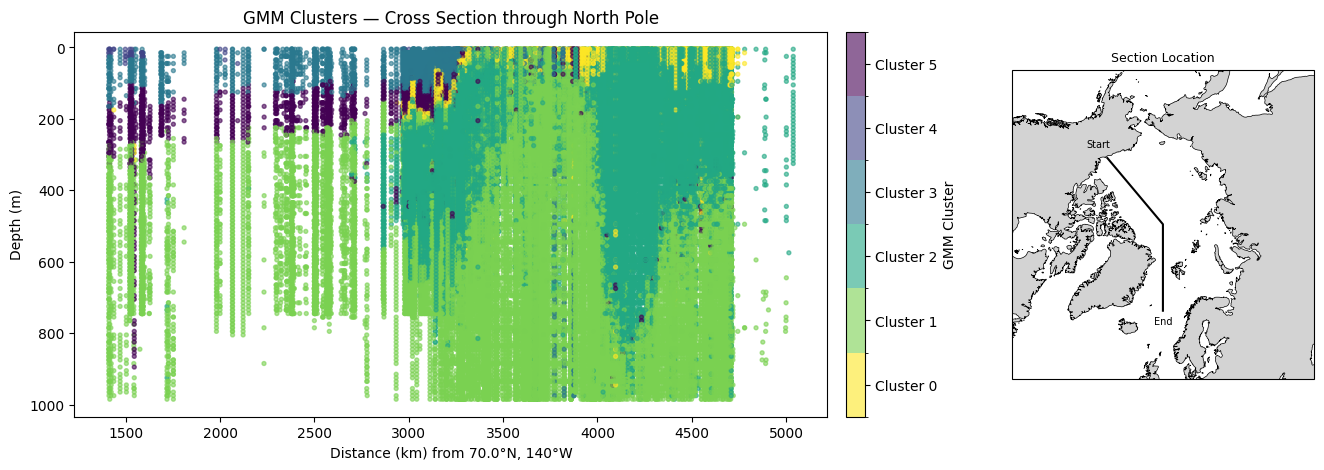

In [34]:
cross_sec_lon(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [139]:
for i in range(n_clusters):
    df_sampled['prob_cluster_'+str(i)] = gmm_0.predict_proba(df_sampled[features])[:, i]

In [75]:
from funcs import compute_great_circle_distance_km
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [222]:
def cross_sec_lon_prob(df_sampled, n_clusters, lon_value, tol=0.5, start_lat=70.0, start_lon=-140.0):

    # Antipodal longitude for the over-pole extension
    lon_antipodal = lon_value + 180 if lon_value < 0 else lon_value - 180

    df_primary = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_sampled['Longitude_[deg_E]'] <= lon_value + tol)
    ].copy()

    df_antipodal = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= lon_antipodal - tol) &
        (df_sampled['Longitude_[deg_E]'] <= lon_antipodal + tol)
    ].copy()

    df_lon_slice = pd.concat([df_primary, df_antipodal], ignore_index=True)

    # Compute great-circle distance from start point
    df_lon_slice['dist_km'] = compute_great_circle_distance_km(
        start_lat, start_lon,
        df_lon_slice['Latitude_[deg_N]'].values,
        df_lon_slice['Longitude_[deg_E]'].values
    )

    # Layout with n_cluster scatter panels and 1 polar map
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(int(np.floor(n_clusters/2)), int(np.floor(n_clusters/2)), width_ratios=[1, 1, 0.5], wspace=0.3, hspace=0.35)

    axes = []
    for i in range(int(np.floor(n_clusters/2))):
        for j in range(int(np.floor(n_clusters/3))):
            axes.append(fig.add_subplot(gs[i, j]))
    
    ax_map = fig.add_subplot(gs[:, 2], projection=ccrs.NorthPolarStereo())

    # ── Plot each cluster probability ─────────────────────────────────────────
    for i, ax in enumerate(axes):
        col = f'prob_cluster_{i}'

        sc = ax.scatter(
            df_lon_slice['dist_km'],
            df_lon_slice['Depth_[m]'],
            c=df_lon_slice[col],
            cmap='viridis',
            vmin=0,
            vmax=1,
            s=n_clusters,
            alpha=0.5
        )

        ax.invert_yaxis()
        ax.set_title(f'Cluster {i} Probability')
        ax.set_xlabel(f'Distance (km) from {start_lat}°N, {abs(start_lon)}°W')
        ax.set_ylabel('Depth (m)')

        cbar = plt.colorbar(sc, ax=ax, pad=0.02)
        cbar.set_label('Probability')

    # ── Polar map (spans both rows on the right) ──────────────────────────────
    end_lat = start_lat
    end_lon = lon_value
    lats_track = [start_lat, 90.0, end_lat]
    lons_track = [start_lon, lon_value, end_lon]

    ax_map.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_map.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)

    ax_map.plot(lons_track, lats_track,
                color='black', linewidth=1.5,
                transform=ccrs.Geodetic(), zorder=3)

    ax_map.text(start_lon, start_lat - 3, 'Start',
                transform=ccrs.PlateCarree(),
                fontsize=7, ha='center', color='black')
    ax_map.text(end_lon, end_lat - 3, 'End',
                transform=ccrs.PlateCarree(),
                fontsize=7, ha='center', color='black')

    ax_map.set_title('Section Location', fontsize=9)

    fig.suptitle(
        f'GMM Cluster Probabilities — Cross Section through North Pole\n',
        fontsize=13
    )

    plt.show()

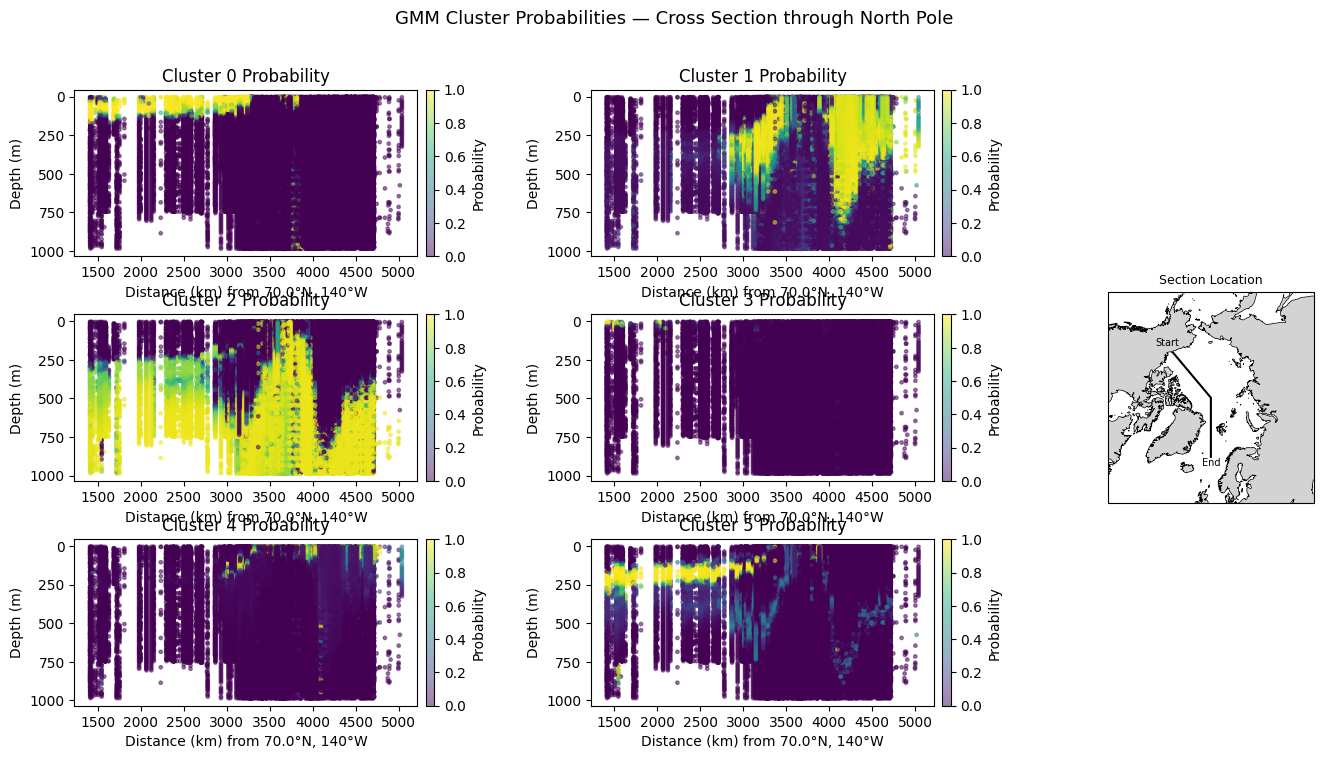

In [223]:
cross_sec_lon_prob(df_sampled,n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [142]:
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

def cross_sec_lon_prob2(
    df_sampled,
    n_clusters,
    lon_value,
    tol=0.5,
    start_lat=70.0,
    start_lon=-140.0,
    max_depth=850,
    depth_bin_size=10,
    dist_bin_size=2.2
):

    # -------------------------------------------------------------------------
    # Antipodal longitude
    # -------------------------------------------------------------------------
    lon_antipodal = lon_value + 180 if lon_value < 0 else lon_value - 180

    # -------------------------------------------------------------------------
    # Select section
    # -------------------------------------------------------------------------
    df_primary = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_sampled['Longitude_[deg_E]'] <= lon_value + tol)
    ].copy()

    df_antipodal = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= lon_antipodal - tol) &
        (df_sampled['Longitude_[deg_E]'] <= lon_antipodal + tol)
    ].copy()

    df_lon_slice = pd.concat(
        [df_primary, df_antipodal],
        ignore_index=True
    )

    # -------------------------------------------------------------------------
    # Depth cutoff
    # -------------------------------------------------------------------------
    df_lon_slice = df_lon_slice[
        df_lon_slice['Depth_[m]'] <= max_depth
    ].copy()

    # -------------------------------------------------------------------------
    # Great-circle distance
    # -------------------------------------------------------------------------
    df_lon_slice['dist_km'] = compute_great_circle_distance_km(
        start_lat,
        start_lon,
        df_lon_slice['Latitude_[deg_N]'].values,
        df_lon_slice['Longitude_[deg_E]'].values
    )

    # -------------------------------------------------------------------------
    # Bin coordinates
    # -------------------------------------------------------------------------
    df_lon_slice['depth_bin'] = (
        np.floor(df_lon_slice['Depth_[m]'] / depth_bin_size)
        * depth_bin_size
    )

    df_lon_slice['dist_bin'] = (
        np.floor(df_lon_slice['dist_km'] / dist_bin_size)
        * dist_bin_size
    )

    # -------------------------------------------------------------------------
    # Average probabilities within bins
    # -------------------------------------------------------------------------
    prob_cols = [f'prob_cluster_{i}' for i in range(n_clusters)]

    df_binned = (
        df_lon_slice
        .groupby(['dist_bin', 'depth_bin'])[prob_cols]
        .mean()
        .reset_index()
    )

    # -------------------------------------------------------------------------
    # Regular plotting grid
    # -------------------------------------------------------------------------
    xi = np.arange(
        df_binned['dist_bin'].min(),
        df_binned['dist_bin'].max(),
        dist_bin_size
    )

    yi = np.arange(
        0,
        max_depth + depth_bin_size,
        depth_bin_size
    )

    XI, YI = np.meshgrid(xi, yi)

    # -------------------------------------------------------------------------
    # Figure
    # -------------------------------------------------------------------------
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(int(np.floor(n_clusters/2)), int(np.floor(n_clusters/2)), 
                          width_ratios=[1, 1, 0.1], wspace=0.4, hspace=0.5)

    axes = []
    for i in range(int(np.floor(n_clusters/2))):
        for j in range(int(np.floor(n_clusters/3))):
            axes.append(fig.add_subplot(gs[i, j]))
    
    cax = fig.add_subplot(gs[:, 2])
    # -------------------------------------------------------------------------
    # Plot each field
    # -------------------------------------------------------------------------
    for i, ax in enumerate(axes):

        col = f'prob_cluster_{i}'
        # -------------------------------------------------------------
        # Interpolate onto regular grid
        # -------------------------------------------------------------
        ZI = griddata(
            (
                df_binned['dist_bin'],
                df_binned['depth_bin']
            ),
            df_binned[col] * 100,
            (XI, YI),
            method='linear'
        )

        # -------------------------------------------------------------
        # Smooth field
        # -------------------------------------------------------------
        ZI = gaussian_filter(ZI, sigma=1.0)

        # -------------------------------------------------------------
        # Plot
        # -------------------------------------------------------------
        pcm = ax.pcolormesh(
            XI,
            YI,
            ZI,
            shading='auto',
            cmap='viridis',
            vmin=0,
            vmax=100)

        # Pole marker
        ax.axvline(
            2200,
            color='white',
            linestyle='--',
            linewidth=1)

        # Formatting
        ax.set_ylim(max_depth, 0)
        ax.set_title(f'Cluster {i} Probability')
        ax.set_xlabel(f'Distance (km) from 70°N, 140°W')
        ax.set_ylabel('Depth (m)')

    # -------------------------------------------------------------------------
    # Shared colorbar
    # -------------------------------------------------------------------------
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label('Probability (%)', fontsize=12)

    # -------------------------------------------------------------------------
    # Title
    # -------------------------------------------------------------------------
    fig.suptitle(
        'GMM Cluster Probabilities — Cross Section through North Pole',
        fontsize=18,
        y=0.98
    )

    plt.tight_layout()
    plt.show()

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67388/4052033780.py:175: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



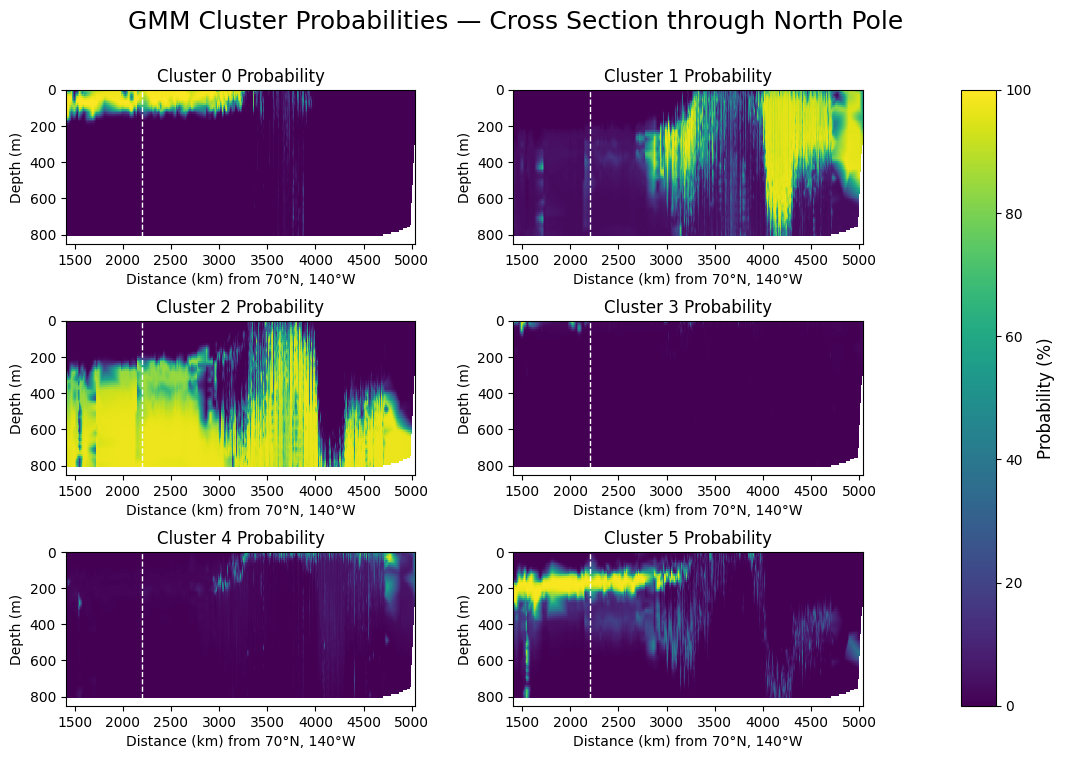

In [143]:
cross_sec_lon_prob2(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [135]:
for i in range(n_clusters):
    df_sampled['prob_cluster_'+str(i)] = gmm_1.predict_proba(df_sampled[features])[:, i]

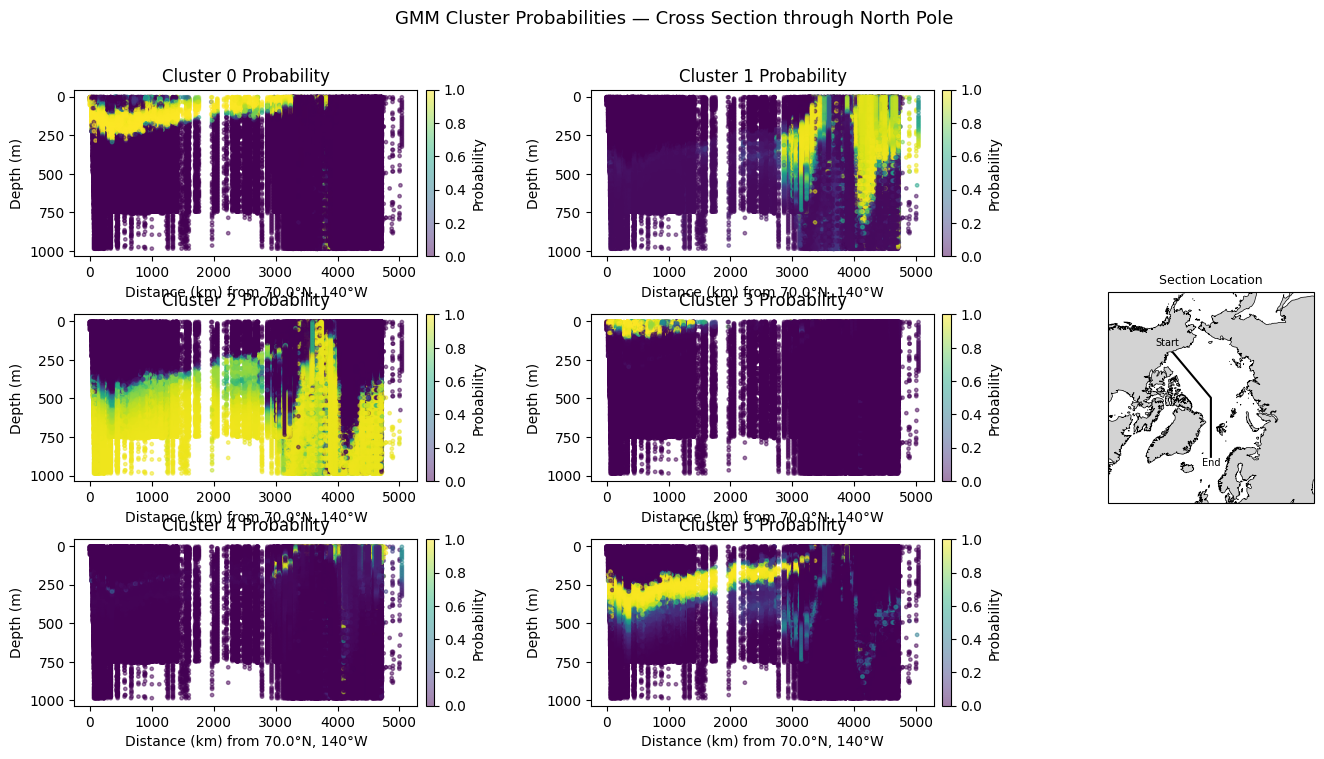

In [238]:
cross_sec_lon_prob(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67388/2997054114.py:132: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



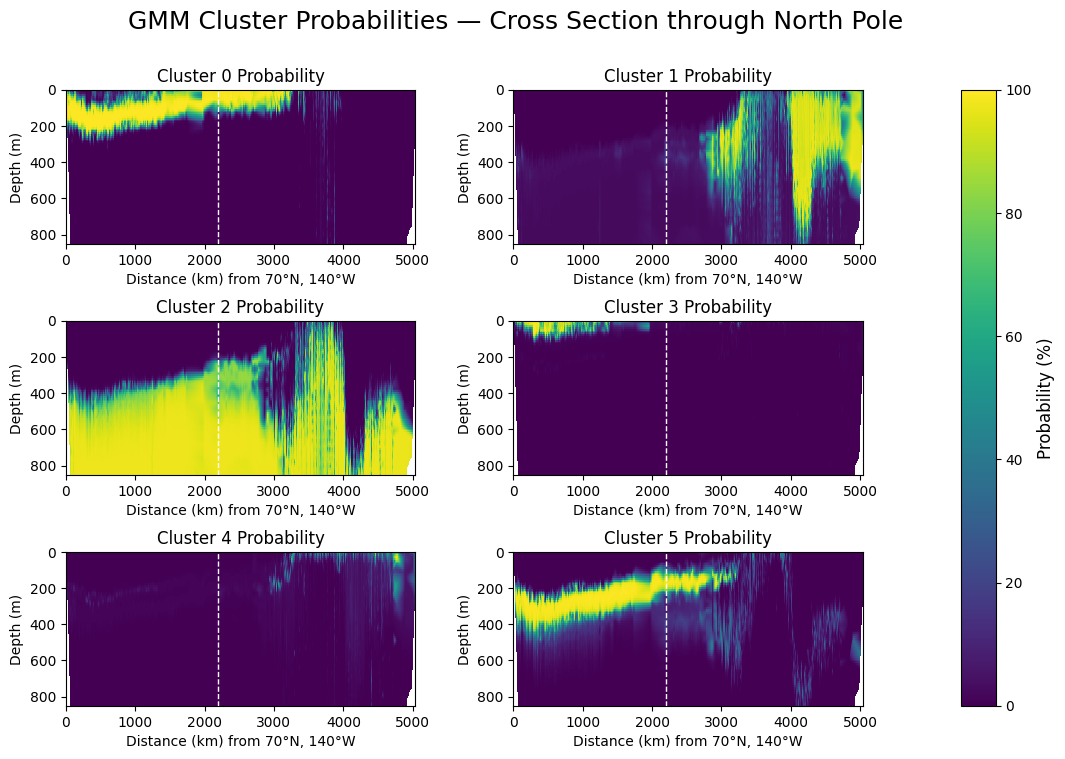

In [239]:
cross_sec_lon_prob2(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

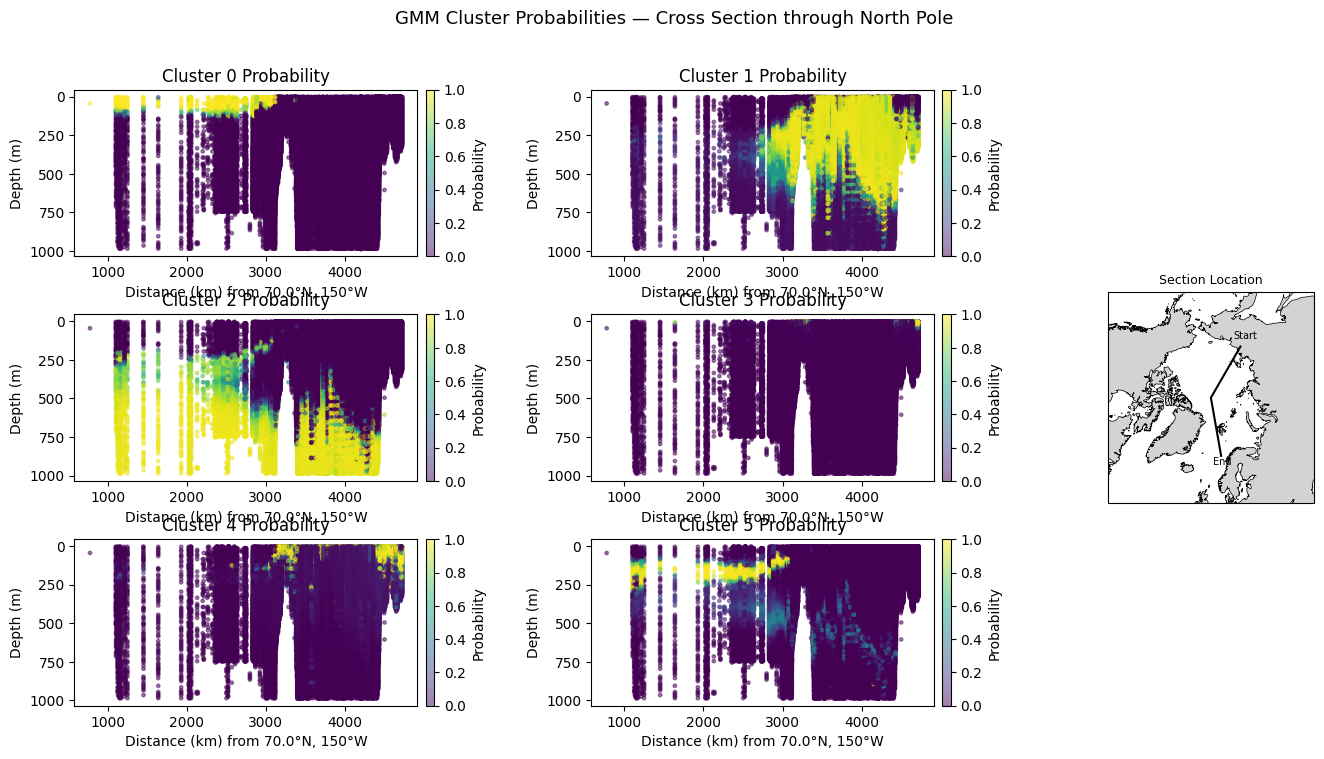

In [235]:
cross_sec_lon_prob(df_sampled, n_clusters, 10, tol=0.5, start_lat=70.0, start_lon=150)

In [210]:
lon_value = 10
tol = 0.5
start_lat = 70.0
start_lon = -140

In [211]:
from pyproj import Geod

In [212]:
def compute_great_circle_distance_km(lat_ref, lon_ref, lats, lons):
    """Compute distance in km from a reference point along a great circle."""
    geod = Geod(ellps='WGS84')
    _, _, dist_m = geod.inv(
        np.full(len(lons), lon_ref),
        np.full(len(lats), lat_ref),
        lons,
        lats
    )
    return dist_m / 1000.0

In [213]:
# Primary slice from start_lon and secondary for lon_value intersecting at the pole
df_primary = df_sampled[
    (df_sampled['Longitude_[deg_E]'] >= start_lon - tol) &
    (df_sampled['Longitude_[deg_E]'] <= start_lon + tol)
].copy()

df_antipodal = df_sampled[
    (df_sampled['Longitude_[deg_E]'] >= lon_value - tol) &
    (df_sampled['Longitude_[deg_E]'] <= lon_value + tol)
].copy()

df_lon_slice = pd.concat([df_primary, df_antipodal], ignore_index=True)

# Compute great-circle distance from start point
df_lon_slice['dist_km'] = compute_great_circle_distance_km(
    start_lat, start_lon,
    df_lon_slice['Latitude_[deg_N]'].values,
    df_lon_slice['Longitude_[deg_E]'].values
)

In [214]:
df_lon_slice['dist_km'].min()

0.03818654127509367

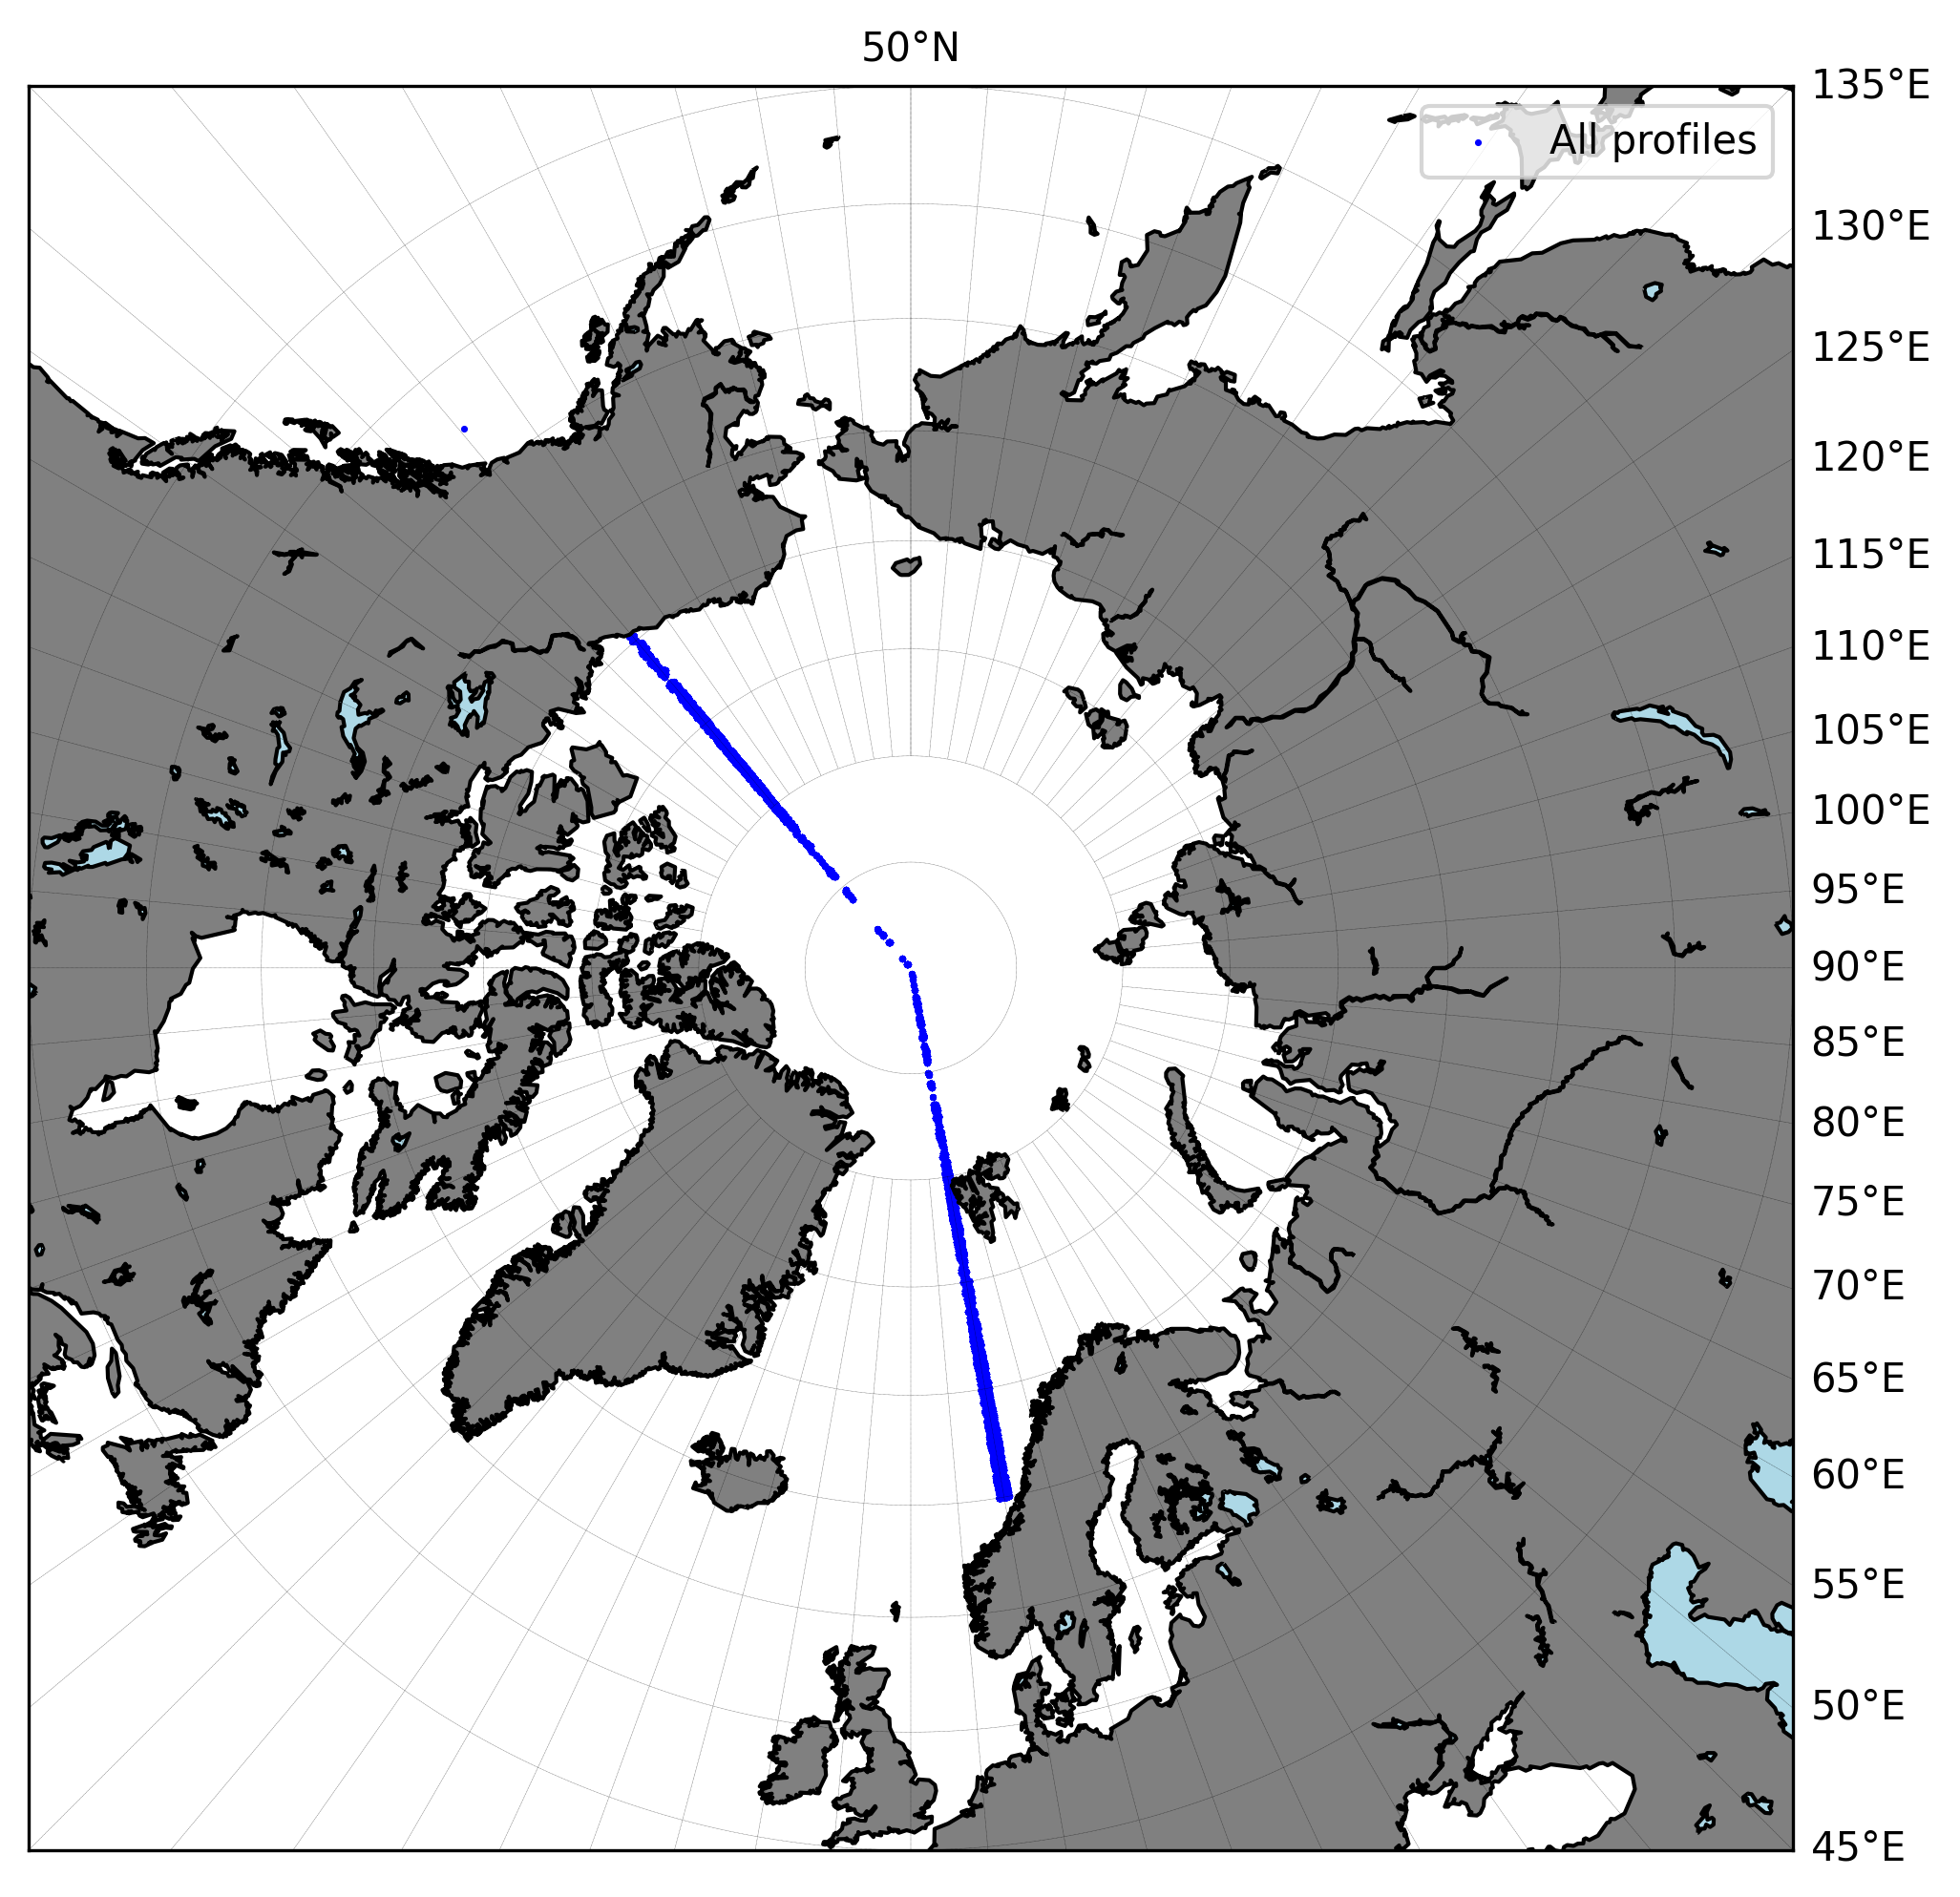

In [228]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# Define the map bounds and resolution
lon_min, lon_max = -180, 180
lat_min, lat_max = 50, 90
latlon_step = 5
resolution = 'l'  # l for low resolution, h for high resolution

# Set up the figure and the Basemap instance
fig = plt.figure(figsize=(8,8),dpi=300)
m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)

parallels = np.arange(lat_min, lat_max+1, 5)
meridians = np.arange(lon_min, lon_max+1, 5)

m.drawparallels(np.arange(lat_min, lat_max+1, latlon_step), labels=[False,False,True,False], linewidth=0.1)
m.drawmeridians(np.arange(lon_min, lon_max+1, latlon_step), labels=[False,True,False,False], linewidth=0.1)


m.drawcoastlines()
m.fillcontinents(color='grey',lake_color='lightblue')

# plot lat lon distribution of the data with pressure length larger than 1
x, y = m(df_lon_slice['Longitude_[deg_E]'].values, df_lon_slice['Latitude_[deg_N]'].values)
m.scatter(x, y, 0.5, marker='o', color='blue',label='All profiles')

# plot the legend on top right
plt.legend(loc='upper right')

# Show the plot
plt.show()

In [245]:
def cross_sec_lon_prob(df_sampled, n_clusters, lon_value, tol=0.5, start_lat=70.0, start_lon=-140.0):
    # Antipodal longitude for the over-pole extension
    #lon_value = lon_value if lon_value <= 180 & lon_value >=0 else lon_value + 180
    if lon_value < 0 and lon_value >= -180:
        lon_value = lon_value + 180

    # Primary slice from start_lon and secondary for lon_value intersecting at the pole
    df_primary = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= start_lon - tol) &
        (df_sampled['Longitude_[deg_E]'] <= start_lon + tol)
    ].copy()

    df_antipodal = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_sampled['Longitude_[deg_E]'] <= lon_value + tol)
    ].copy()

    df_lon_slice = pd.concat([df_primary, df_antipodal], ignore_index=True)

    # Compute great-circle distance from start point
    df_lon_slice['dist_km'] = compute_great_circle_distance_km(
        start_lat, start_lon,
        df_lon_slice['Latitude_[deg_N]'].values,
        df_lon_slice['Longitude_[deg_E]'].values
    )

    # Layout with n_cluster scatter panels and 1 polar map
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(int(np.floor(n_clusters/2)), int(np.floor(n_clusters/2)), width_ratios=[1, 1, 0.5], wspace=0.3, hspace=0.35)

    axes = []
    for i in range(int(np.floor(n_clusters/2))):
        for j in range(int(np.floor(n_clusters/3))):
            axes.append(fig.add_subplot(gs[i, j]))
    
    ax_map = fig.add_subplot(gs[:, 2], projection=ccrs.NorthPolarStereo())

    # ── Plot each cluster probability ─────────────────────────────────────────
    for i, ax in enumerate(axes):
        col = f'prob_cluster_{i}'

        sc = ax.scatter(
            df_lon_slice['dist_km'],
            df_lon_slice['Depth_[m]'],
            c=df_lon_slice[col],
            cmap='viridis',
            vmin=0,
            vmax=1,
            s=n_clusters,
            alpha=0.5
        )

        ax.invert_yaxis()
        ax.set_title(f'Cluster {i} Probability')
        ax.set_xlabel(f'Distance (km) from {start_lat}°N, {abs(start_lon)}°W')
        ax.set_ylabel('Depth (m)')

        cbar = plt.colorbar(sc, ax=ax, pad=0.02)
        cbar.set_label('Probability')

    # ── Polar map (spans both rows on the right) ──────────────────────────────
    end_lat = start_lat
    end_lon = lon_value
    lats_track = [start_lat, 90.0, end_lat]
    lons_track = [start_lon, lon_value, end_lon]

    ax_map.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_map.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)

    ax_map.plot(lons_track, lats_track,
                color='black', linewidth=1.5,
                transform=ccrs.Geodetic(), zorder=3)

    ax_map.text(start_lon, start_lat - 3, 'Start',
                transform=ccrs.PlateCarree(),
                fontsize=7, ha='center', color='black')
    ax_map.text(end_lon, end_lat - 3, 'End',
                transform=ccrs.PlateCarree(),
                fontsize=7, ha='center', color='black')

    ax_map.set_title('Section Location', fontsize=9)

    fig.suptitle(
        f'GMM Cluster Probabilities — Cross Section through North Pole\n',
        fontsize=13
    )

    plt.show()

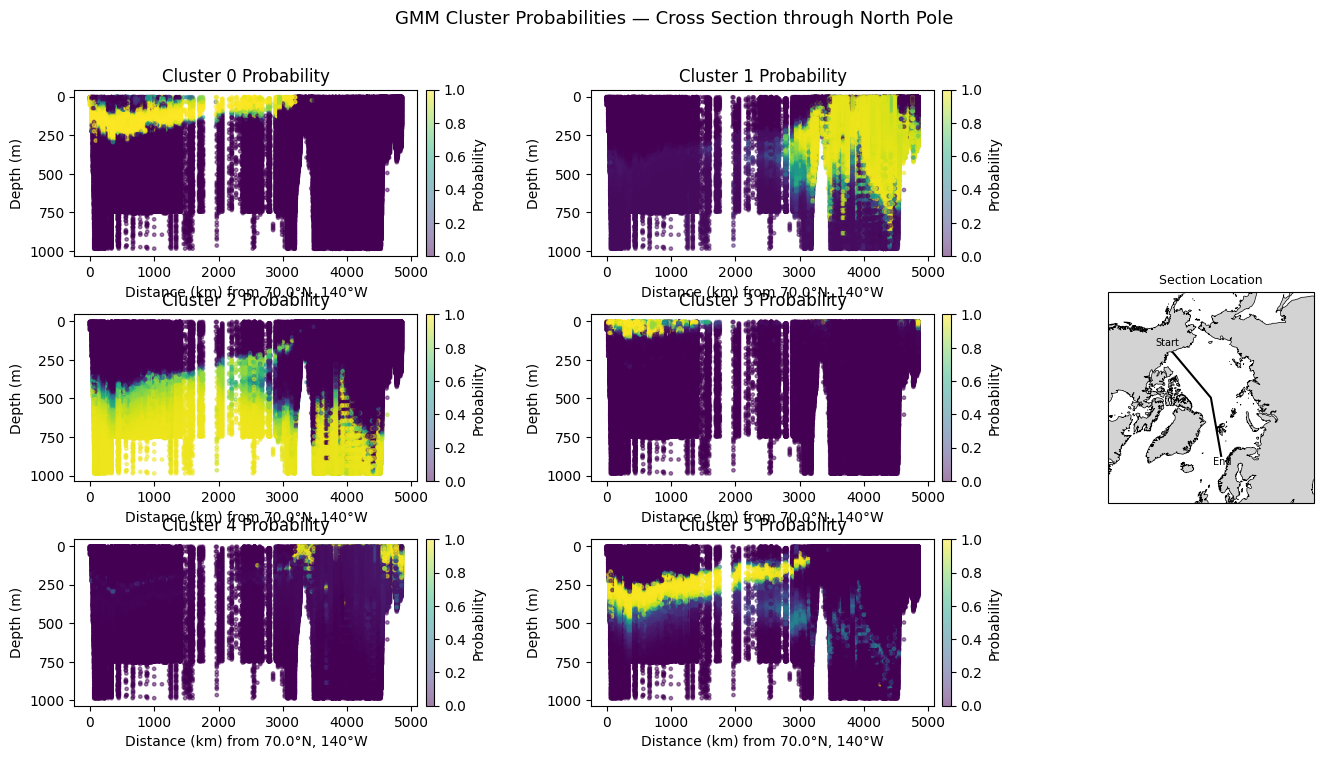

In [246]:
cross_sec_lon_prob(df_sampled, n_clusters, -170, tol=0.5, start_lat=70.0, start_lon=-140)

In [247]:
def cross_sec_lon_prob2(
    df_sampled,
    n_clusters,
    lon_value,
    tol=0.5,
    start_lat=70.0,
    start_lon=-140.0,
    max_depth=850,
    depth_bin_size=10,
    dist_bin_size=2.2
):
    # Antipodal longitude for the over-pole extension
    if lon_value < 0 and lon_value >= -180:
        lon_value = lon_value + 180
        
    # Primary slice from start_lon and secondary for lon_value intersecting at the pole
    df_primary = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= start_lon - tol) &
        (df_sampled['Longitude_[deg_E]'] <= start_lon + tol)
    ].copy()

    df_antipodal = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_sampled['Longitude_[deg_E]'] <= lon_value + tol)
    ].copy()

    df_lon_slice = pd.concat([df_primary, df_antipodal], ignore_index=True)

    # Compute great-circle distance from start point
    df_lon_slice['dist_km'] = compute_great_circle_distance_km(
        start_lat, start_lon,
        df_lon_slice['Latitude_[deg_N]'].values,
        df_lon_slice['Longitude_[deg_E]'].values
    )

    # Bin coordinates
    df_lon_slice['depth_bin'] = (
        np.floor(df_lon_slice['Depth_[m]'] / depth_bin_size)
        * depth_bin_size
    )

    df_lon_slice['dist_bin'] = (
        np.floor(df_lon_slice['dist_km'] / dist_bin_size)
        * dist_bin_size
    )

    # Average probabilities within bins
    prob_cols = [f'prob_cluster_{i}' for i in range(n_clusters)]

    df_binned = (
        df_lon_slice
        .groupby(['dist_bin', 'depth_bin'])[prob_cols]
        .mean()
        .reset_index()
    )

    # Regular plotting grid
    xi = np.arange(
        df_binned['dist_bin'].min(),
        df_binned['dist_bin'].max(),
        dist_bin_size
    )

    yi = np.arange(
        0,
        max_depth + depth_bin_size,
        depth_bin_size
    )

    XI, YI = np.meshgrid(xi, yi)

    # Figure
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(int(np.floor(n_clusters/2)), int(np.floor(n_clusters/2)), 
                          width_ratios=[1, 1, 0.1], wspace=0.4, hspace=0.5)

    axes = []
    for i in range(int(np.floor(n_clusters/2))):
        for j in range(int(np.floor(n_clusters/3))):
            axes.append(fig.add_subplot(gs[i, j]))
    
    cax = fig.add_subplot(gs[:, 2])
    # Plot each field
    for i, ax in enumerate(axes):

        col = f'prob_cluster_{i}'
        # Interpolate onto regular grid
        ZI = griddata(
            (
                df_binned['dist_bin'],
                df_binned['depth_bin']
            ),
            df_binned[col] * 100,
            (XI, YI),
            method='linear'
        )

        # Smooth field
        ZI = gaussian_filter(ZI, sigma=1.0)

        # Plot
        pcm = ax.pcolormesh(
            XI,
            YI,
            ZI,
            shading='auto',
            cmap='viridis',
            vmin=0,
            vmax=100)

        # Pole marker
        ax.axvline(
            2200,
            color='white',
            linestyle='--',
            linewidth=1)

        # Formatting
        ax.set_ylim(max_depth, 0)
        ax.set_title(f'Cluster {i} Probability')
        ax.set_xlabel(f'Distance (km) from 70°N, 140°W')
        ax.set_ylabel('Depth (m)')

    # Shared colorbar
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label('Probability (%)', fontsize=12)

    # Title
    fig.suptitle(
        'GMM Cluster Probabilities — Cross Section through North Pole',
        fontsize=18,
        y=0.98
    )

    plt.tight_layout()
    plt.show()

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67388/3009811550.py:135: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



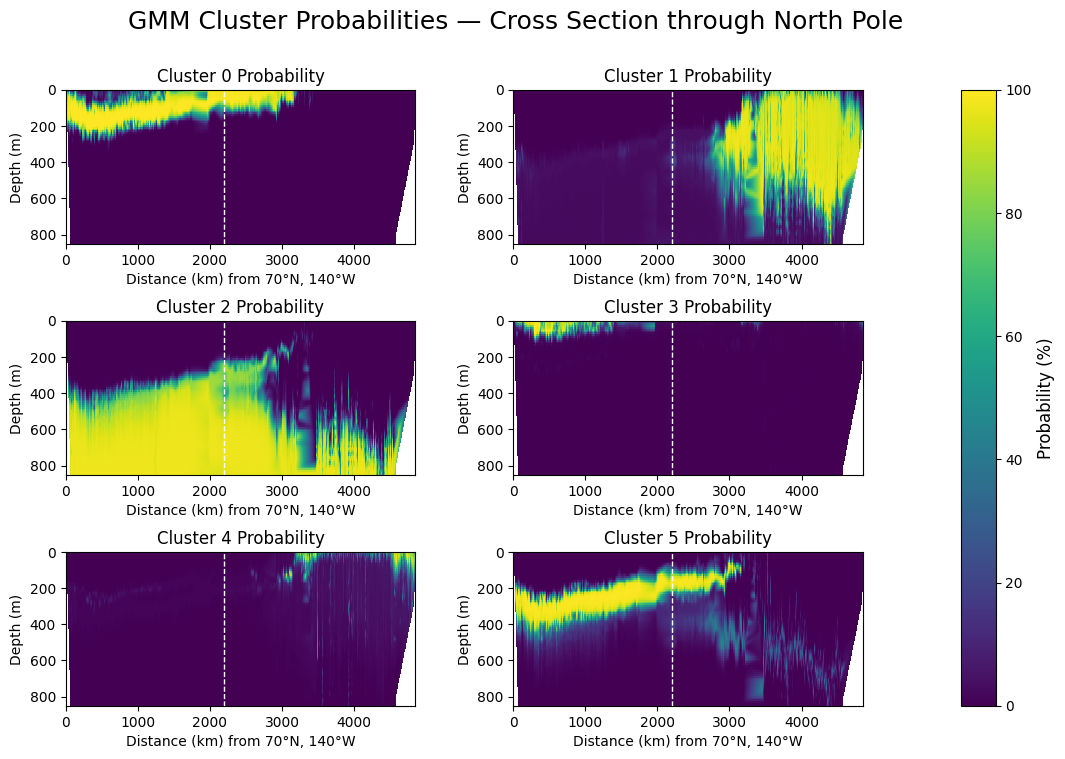

In [249]:
cross_sec_lon_prob2(df_sampled, n_clusters, -170, tol=0.5, start_lat=70.0, start_lon=-140)